<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Markowitz_Model_Demonstration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import matplotlib.pyplot as plt
import scipy.optimize as optimization
import numpy as np
import yfinance as yf
import pandas as pd

In [45]:
TRADING_DAYS = 252
PORTFOLIOS = 100000
start_date= "2013-09-01"
end_date="2025-08-15"
stocks='GOOG', 'MSFT', 'AAPL', 'AMZN', 'NVDA', 'AMD', 'TSLA'

In [46]:
# Download yfinance data for selected stocks, from start_date - end_date
def download_data(start_date, end_date, stocks):
    close_data = {}
    for s in stocks:
        ticker = yf.Ticker(s)
        close_data[s] = ticker.history(start=start_date, end=end_date)['Close']
    return pd.DataFrame(close_data)

In [44]:
# Compute noralized log returns for each stock
def compute_returns(data):
    # Normalize with logs
    log_return = np.log(data / data.shift(1))
    return log_return[1:]

In [16]:
# Compute mean and covariance of returns
def compute_statistics(returns):
    # Mean of annual return
    print('ANNUAL MEAN: \n' + str(returns.mean() * TRADING_DAYS))
    print('\nCOVARIANCE MATRIX: \n' + str(returns.cov() * TRADING_DAYS))

In [17]:
# Compute mean and volatility of portfolio
def compute_mean_variance(returns, weights):
    ret = np.sum(returns.mean() * weights) * TRADING_DAYS
    vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * TRADING_DAYS, weights)))
    print('Expected portfolio mean: '+ str(ret))
    print('Expected portfolio volatility: '+ str(vol))

In [18]:
# Generate random portfolios
def generate_portfolios(returns, stocks):
    means = []
    risks = []
    weights = []

    for _ in range(PORTFOLIOS):
        weight = np.random.random(len(stocks))
        weight /= np.sum(weight)
        mean = np.sum(returns.mean() * weight) * TRADING_DAYS
        risk = np.sqrt(np.dot(weight.T, np.dot(returns.cov() * TRADING_DAYS, weight)))
        weights.append(weight)
        means.append(mean)
        risks.append(risk)

    return np.array(weights), np.array(means), np.array(risks)

In [19]:
# Portfolio statistics, containing returns, volatility and sharpe ratio
def portfolio_statistics(weights, returns):
    ret = np.sum(returns.mean() * weights) * TRADING_DAYS
    vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() * TRADING_DAYS, weights)))
    return np.array([ret, vol, ret/vol])

def minimize_sharpe_ratio(weights, returns):
    return -portfolio_statistics(weights, returns)[2]


In [20]:
# Minimize f(x) = 0, where sum of weights equivalent to 1
def optimize_portfolio(weights, returns, stocks):
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(stocks)))
    optimum = optimization.minimize(fun=minimize_sharpe_ratio, x0=weights[0], args=returns,
                                    method='SLSQP', bounds=bounds, constraints=constraints)
    print('Optimal portfolio: ' + str(optimum['x'].round(3)))
    print('Expected return, volatility and Sharpe ratio: ' + str(portfolio_statistics(optimum['x'].round(3), returns)))
    return optimum

In [21]:
# Plot data
def plot_data(data):
    data.plot(figsize=(10, 6))
    plt.show()

# Plot portfolios
def plot_portfolios(returns, vol):
    plt.figure(figsize=(10, 6))
    plt.grid(True)
    plt.scatter(vol, returns, c=returns/vol, marker='o')
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.show()

# Plot optimal portfolio
def plot_optimal_portfolio(opt, returns, portfolio_returns, vol):
    plt.figure(figsize=(10, 6))
    plt.grid(True)
    plt.scatter(vol, portfolio_returns, c=portfolio_returns/vol, marker='o')
    plt.xlabel('Expected Volatility')
    plt.ylabel('Expected Return')
    plt.colorbar(label='Sharpe Ratio')
    plt.plot(portfolio_statistics(opt['x'], returns)[1], portfolio_statistics(opt['x'], returns)[0], 'g*', markersize=20.0)
    plt.show()

In [24]:
stocks = ['GOOG', 'MSFT', 'AAPL', 'AMZN', 'NVDA', 'AMD', 'TSLA']
start_date = '2013-09-01'
end_date = '2025-08-15'

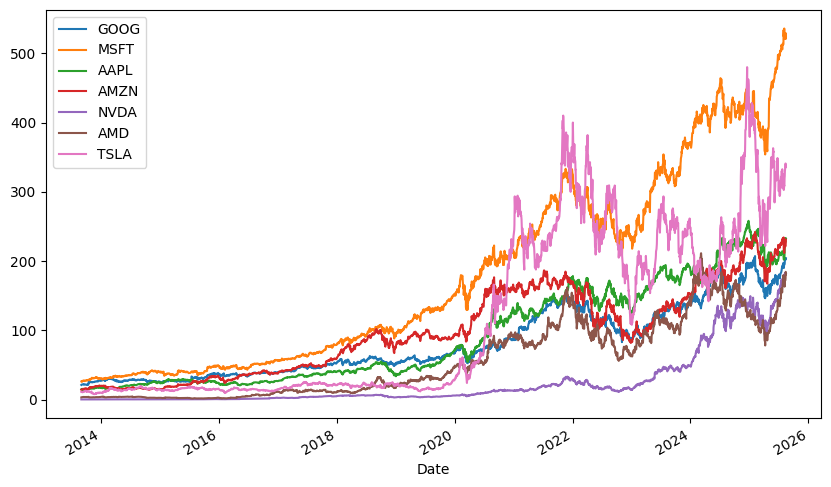

In [25]:
data = download_data(start_date, end_date, stocks)
plot_data(data)

In [26]:
returns = compute_returns(data)
compute_statistics(returns)

ANNUAL MEAN: 
GOOG    0.189391
MSFT    0.250521
AAPL    0.229496
AMZN    0.232488
NVDA    0.525397
AMD     0.336567
TSLA    0.284652
dtype: float64

COVARIANCE MATRIX: 
          GOOG      MSFT      AAPL      AMZN      NVDA       AMD      TSLA
GOOG  0.078987  0.050451  0.045636  0.058439  0.069144  0.059829  0.061092
MSFT  0.050451  0.069633  0.047929  0.053948  0.073622  0.063142  0.059791
AAPL  0.045636  0.047929  0.080677  0.049500  0.069114  0.066173  0.068514
AMZN  0.058439  0.053948  0.049500  0.107477  0.077964  0.074500  0.074612
NVDA  0.069144  0.073622  0.069114  0.077964  0.217948  0.153717  0.109207
AMD   0.059829  0.063142  0.066173  0.074500  0.153717  0.314156  0.111746
TSLA  0.061092  0.059791  0.068514  0.074612  0.109207  0.111746  0.328714


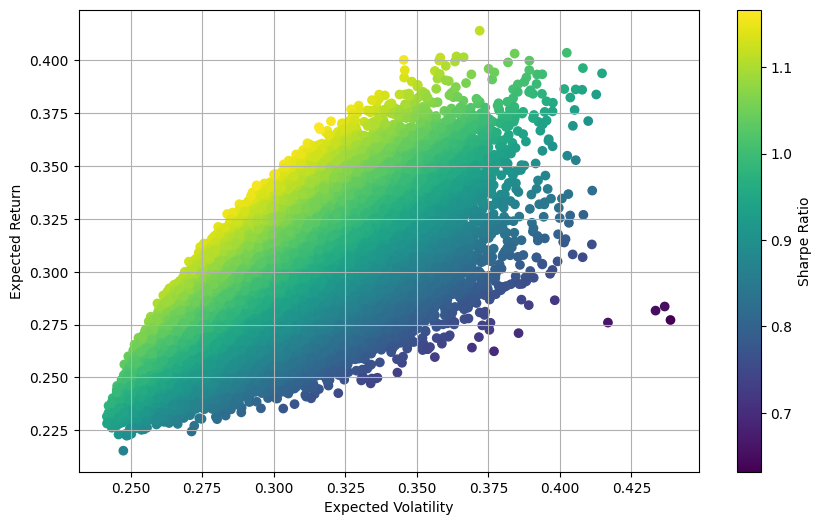

In [27]:
#Generate random portfolios
weights, means, risks = generate_portfolios(returns, stocks)
plot_portfolios(means, risks)

Optimal portfolio: [0.    0.371 0.138 0.    0.491 0.    0.   ]
Expected return, volatility and Sharpe ratio: [0.38258341 0.32366588 1.18203194]


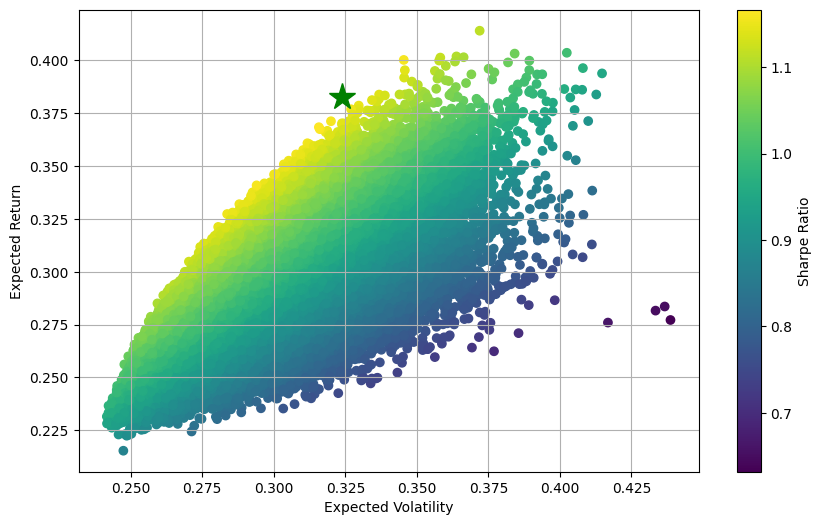

In [28]:
#Portfolio Optimization
optimum = optimize_portfolio(weights, returns, stocks)
plot_optimal_portfolio(optimum, returns, means, risks)

In [ ]:
#In conclusion, our optimal portfolio is highlighted with the 'green star marker', evinced by the Markowitz model for portfolio optimization.